# Build Status Evaluation

This notebook loads every JSON report from `validations/build_status_reports/reports` and converts the public `status --json` payload into pandas data frames for analysis.

The notebook assumes the simplified public schema:
- direct counts only
- grouped sections: `structure`, `callsites`, `pre_persist_filter`, `call_materialization`
- top-level `timing`
- partitions at totals, per-language, and per-scope (`non_tests`, `tests`)

All derived metrics, aggregations, tables, and plots are computed here rather than stored in the JSON reports.


## Definitions

Public sections used in the reports:

- `structure`: `files`, `nodes`, `edges`
- `structure.files` and `structure.nodes` are structural counts
- `structure.edges` is the total reducer-facing graph edge count, including structural edges and `CALLS`, attributed by source node
- `callsites`: `observed_syntactic_callsites`, `filtered_pre_persist`, `persisted_callsites`, `persisted_accepted`, `persisted_dropped`
- `pre_persist_filter`: `no_in_repo_candidate`, `accepted_outside_in_repo`, `invalid_observation_shape`
- `call_materialization`: `callsite_pairs`, `finalized_call_edges`
- `timing`: `build_total_seconds`, `build_wall_seconds`, `build_phase_timings`

This notebook exposes:
- `reports`: raw loaded report payloads keyed by repo name
- `repo_df`: one row per repository from `report.totals`
- `language_df`: one row per repository/language
- `scope_df`: one row per repository/scope
- `phase_long_df`: one row per repository/build phase
- `phase_wide_df`: pivoted phase timing table
- `label_tables`: centralized labels from the report payloads


In [1]:
from __future__ import annotations

from pathlib import Path
import json

import pandas as pd

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None


In [2]:
def resolve_reports_dir() -> Path:
    candidates = [
        Path.cwd() / 'reports',
        Path.cwd() / 'validations' / 'build_status_reports' / 'reports',
        Path.cwd().parent / 'reports',
        Path('/Users/dc/Calculations/sciona-suite/sciona/validations/build_status_reports/reports'),
    ]
    for candidate in candidates:
        if candidate.exists() and candidate.is_dir():
            return candidate.resolve()
    raise FileNotFoundError('Could not locate validations/build_status_reports/reports')

REPORTS_DIR = resolve_reports_dir()
REPORT_PATHS = sorted(REPORTS_DIR.glob('*.json'))
if not REPORT_PATHS:
    raise FileNotFoundError(f'No JSON reports found in {REPORTS_DIR}')

REPORTS_DIR, len(REPORT_PATHS), [p.name for p in REPORT_PATHS[:5]]


(PosixPath('/Users/dc/Calculations/sciona-suite/sciona/validations/build_status_reports/reports'),
 10,
 ['airbyte.json',
  'axios.json',
  'commons-lang.json',
  'fastapi.json',
  'guava.json'])

In [3]:
reports: dict[str, dict] = {}
for path in REPORT_PATHS:
    repo = path.stem
    reports[repo] = json.loads(path.read_text(encoding='utf-8'))

sorted(reports), len(reports)


(['airbyte',
  'axios',
  'commons-lang',
  'fastapi',
  'guava',
  'nest',
  'pydantic',
  'sympy',
  'vscode',
  'webpack'],
 10)

In [4]:
def flatten_section(prefix: str, section: dict | None) -> dict[str, object]:
    section = section or {}
    return {f'{prefix}.{key}': value for key, value in section.items()}


def flatten_summary_entry(base: dict[str, object], entry: dict | None) -> dict[str, object]:
    entry = entry or {}
    row = dict(base)
    row.update(flatten_section('structure', entry.get('structure')))
    row.update(flatten_section('callsites', entry.get('callsites')))
    row.update(flatten_section('pre_persist_filter', entry.get('pre_persist_filter')))
    row.update(flatten_section('call_materialization', entry.get('call_materialization')))
    return row


def raw_report(report: dict) -> dict:
    return report.get('report') or {}


def report_for(repo: str) -> dict:
    return reports[repo]


def report_body_for(repo: str) -> dict:
    return raw_report(reports[repo])


In [5]:
repo_rows = []
language_rows = []
scope_rows = []
phase_rows = []
label_tables = {}

for repo, report in sorted(reports.items()):
    report_body = raw_report(report)
    labels = report_body.get('labels') or {}
    if labels:
        label_tables[repo] = labels

    timing = report_body.get('timing') or {}
    repo_rows.append(
        flatten_summary_entry(
            {
                'repo': repo,
                'snapshot_id': report.get('latest_snapshot'),
                'created_at': report.get('latest_created'),
                'artifact_db_available': report.get('artifact_db_available'),
                'timing.build_total_seconds': timing.get('build_total_seconds'),
                'timing.build_wall_seconds': timing.get('build_wall_seconds'),
            },
            report_body.get('totals'),
        )
    )

    for language_entry in report_body.get('languages') or []:
        language_rows.append(
            flatten_summary_entry(
                {'repo': repo, 'language': language_entry.get('language')},
                language_entry,
            )
        )

    for scope_name, scope_entry in (report_body.get('scopes') or {}).items():
        scope_rows.append(
            flatten_summary_entry(
                {'repo': repo, 'scope': scope_name},
                scope_entry,
            )
        )

    for phase, seconds in (timing.get('build_phase_timings') or {}).items():
        phase_rows.append({'repo': repo, 'phase': phase, 'seconds': seconds})

repo_df = pd.DataFrame(repo_rows).sort_values('repo').reset_index(drop=True)
language_df = pd.DataFrame(language_rows).sort_values(['repo', 'language']).reset_index(drop=True)
scope_df = pd.DataFrame(scope_rows).sort_values(['repo', 'scope']).reset_index(drop=True)
phase_long_df = pd.DataFrame(phase_rows).sort_values(['repo', 'phase']).reset_index(drop=True)
phase_wide_df = phase_long_df.pivot(index='repo', columns='phase', values='seconds').sort_index() if not phase_long_df.empty else pd.DataFrame()

repo_df.head()


,repo,snapshot_id,created_at,artifact_db_available,timing.build_total_seconds,timing.build_wall_seconds,structure.files,structure.nodes,structure.edges,callsites.observed_syntactic_callsites,callsites.filtered_pre_persist,callsites.persisted_callsites,callsites.persisted_accepted,callsites.persisted_dropped,pre_persist_filter.no_in_repo_candidate,pre_persist_filter.accepted_outside_in_repo,pre_persist_filter.invalid_observation_shape,call_materialization.callsite_pairs,call_materialization.finalized_call_edges
0,airbyte,93b007d0441b1d5d2cd74f0231a51a228454a408cf78ec...,2026-03-14T10:22:04.173900+00:00,True,56.680577,59.853205,3288,25275,38063,15626,896,14730,14441,289,896,0,0,14453,13613
1,axios,cad556337bcde75053c145f7ee399809f393ea80bcb673...,2026-03-13T20:50:07.464005+00:00,True,2.711332,3.296952,173,576,805,231,66,165,161,4,0,0,0,165,163
2,commons-lang,1b31d23af02dd1a48d261a94d34244f1ac0a819ce68afd...,2026-03-13T20:26:14.074950+00:00,True,17.836203,18.703744,534,11566,17316,5692,205,5487,5376,111,0,0,0,5718,5713
3,fastapi,93b8eef40f4117fca1eac25bc7397263d988c7b916a816...,2026-03-14T10:17:43.017145+00:00,True,10.368963,11.348754,1287,6604,7754,2310,1078,1232,716,516,1078,0,0,716,716
4,guava,0540ba1d87621453a27ad9b1664b4ec0e2f2ea88d42b74...,2026-03-13T20:27:17.348738+00:00,True,98.947527,101.712757,3245,64131,103276,36639,1266,35373,34844,529,0,0,0,36099,36064


## Loading Summary

The next cells show the raw public labels and the core flattened tables built from the JSON reports.


In [6]:
first_repo = sorted(label_tables)[0]
label_tables[first_repo]


{'sections': {'structure': 'Structure',
  'callsites': 'Callsites',
  'pre_persist_filter': 'Pre-Persist Filter',
  'call_materialization': 'Call Materialization',
  'timing': 'Timing'},
 'fields': {'files': 'Files',
  'nodes': 'Nodes',
  'edges': 'Edges',
  'observed_syntactic_callsites': 'Observed Syntactic Callsites',
  'filtered_pre_persist': 'Filtered Pre-Persist',
  'persisted_callsites': 'Persisted Callsites',
  'persisted_accepted': 'Persisted Accepted',
  'persisted_dropped': 'Persisted Dropped',
  'no_in_repo_candidate': 'No In-Repo Candidate',
  'accepted_outside_in_repo': 'Accepted Outside In-Repo',
  'invalid_observation_shape': 'Invalid Observation Shape',
  'callsite_pairs': 'Callsite Pairs',
  'finalized_call_edges': 'Finalized Call Edges',
  'build_total_seconds': 'Build Total Seconds',
  'build_wall_seconds': 'Build Wall Seconds'},
 'scopes': {'non_tests': 'Non-Tests', 'tests': 'Tests'},
 'phases': {'compute_build_fingerprint': 'Compute Build Fingerprint',
  'discover

In [7]:
repo_df


,repo,snapshot_id,created_at,artifact_db_available,timing.build_total_seconds,timing.build_wall_seconds,structure.files,structure.nodes,structure.edges,callsites.observed_syntactic_callsites,callsites.filtered_pre_persist,callsites.persisted_callsites,callsites.persisted_accepted,callsites.persisted_dropped,pre_persist_filter.no_in_repo_candidate,pre_persist_filter.accepted_outside_in_repo,pre_persist_filter.invalid_observation_shape,call_materialization.callsite_pairs,call_materialization.finalized_call_edges
0,airbyte,93b007d0441b1d5d2cd74f0231a51a228454a408cf78ec...,2026-03-14T10:22:04.173900+00:00,True,56.680577,59.853205,3288,25275,38063,15626,896,14730,14441,289,896,0,0,14453,13613
1,axios,cad556337bcde75053c145f7ee399809f393ea80bcb673...,2026-03-13T20:50:07.464005+00:00,True,2.711332,3.296952,173,576,805,231,66,165,161,4,0,0,0,165,163
2,commons-lang,1b31d23af02dd1a48d261a94d34244f1ac0a819ce68afd...,2026-03-13T20:26:14.074950+00:00,True,17.836203,18.703744,534,11566,17316,5692,205,5487,5376,111,0,0,0,5718,5713
3,fastapi,93b8eef40f4117fca1eac25bc7397263d988c7b916a816...,2026-03-14T10:17:43.017145+00:00,True,10.368963,11.348754,1287,6604,7754,2310,1078,1232,716,516,1078,0,0,716,716
4,guava,0540ba1d87621453a27ad9b1664b4ec0e2f2ea88d42b74...,2026-03-13T20:27:17.348738+00:00,True,98.947527,101.712757,3245,64131,103276,36639,1266,35373,34844,529,0,0,0,36099,36064
5,nest,e496c2ebda9ea47c65abe97544bc89e0335a4f7d8f1d21...,2026-03-13T20:29:17.739580+00:00,True,12.904787,13.843845,1708,6416,10200,2353,342,2011,1952,59,0,0,0,2203,2195
6,pydantic,245d5326ed348def34c6e8d9163c016b6967ab5e06410b...,2026-03-13T20:29:45.001908+00:00,True,17.245171,18.034667,407,13301,16283,3263,848,2415,2273,142,0,0,0,2273,2264
7,sympy,113bcd9593064be749a526adbe2a51ceae2ff90960dfa3...,2026-03-13T20:31:19.263227+00:00,True,140.154272,142.231974,1590,40980,99191,72663,25344,47319,47109,210,0,0,0,47109,46558
8,vscode,f76c03fe1e627cd3a97028fc7085619b028a9d036d0e91...,2026-03-13T20:34:13.301648+00:00,True,658.436541,665.129938,6765,108097,346645,155451,10208,145243,141486,3757,0,0,0,176856,175171
9,webpack,93c2336ede3fac7eec48d0dea503b2d1f69cebde426e7d...,2026-03-13T20:30:18.342087+00:00,True,43.080722,45.310896,8703,14945,14428,3368,156,3212,3135,77,0,0,0,3189,3175


In [8]:
language_df


,repo,language,structure.files,structure.nodes,structure.edges,callsites.observed_syntactic_callsites,callsites.filtered_pre_persist,callsites.persisted_callsites,callsites.persisted_accepted,callsites.persisted_dropped,pre_persist_filter.no_in_repo_candidate,pre_persist_filter.accepted_outside_in_repo,pre_persist_filter.invalid_observation_shape,call_materialization.callsite_pairs,call_materialization.finalized_call_edges
0,airbyte,java,473,4144,5397,1623,54,1569,1556,13,54,0,0,1568,1568
1,airbyte,javascript,44,147,180,53,0,53,53,0,0,0,0,53,53
2,airbyte,python,2768,20976,32478,13948,842,13106,12830,276,842,0,0,12830,11990
3,airbyte,typescript,3,8,8,2,0,2,2,0,0,0,0,2,2
4,axios,javascript,167,438,673,231,66,165,161,4,0,0,0,165,163
5,axios,typescript,6,138,132,0,0,0,0,0,0,0,0,0,0
6,commons-lang,java,534,11566,17316,5692,205,5487,5376,111,0,0,0,5718,5713
7,fastapi,javascript,3,25,44,22,0,22,22,0,0,0,0,22,22
8,fastapi,python,1284,6579,7710,2288,1078,1210,694,516,1078,0,0,694,694
9,guava,java,3243,64129,103276,36639,1266,35373,34844,529,0,0,0,36099,36064


In [9]:
scope_df


,repo,scope,structure.files,structure.nodes,structure.edges,callsites.observed_syntactic_callsites,callsites.filtered_pre_persist,callsites.persisted_callsites,callsites.persisted_accepted,callsites.persisted_dropped,pre_persist_filter.no_in_repo_candidate,pre_persist_filter.accepted_outside_in_repo,pre_persist_filter.invalid_observation_shape,call_materialization.callsite_pairs,call_materialization.finalized_call_edges
0,airbyte,non_tests,3098,23583,35939,15012,891,14121,13836,285,891,0,0,13848,13008
1,airbyte,tests,190,1692,2124,614,5,609,605,4,5,0,0,605,605
2,axios,non_tests,94,449,679,224,66,158,154,4,0,0,0,158,156
3,axios,tests,79,127,126,7,0,7,7,0,0,0,0,7,7
4,commons-lang,non_tests,259,4973,8643,3403,7,3396,3325,71,0,0,0,3667,3662
5,commons-lang,tests,275,6593,8673,2289,198,2091,2051,40,0,0,0,2051,2051
6,fastapi,non_tests,721,2457,3059,739,279,460,453,7,279,0,0,453,453
7,fastapi,tests,566,4147,4695,1571,799,772,263,509,799,0,0,263,263
8,guava,non_tests,2001,36684,64507,23556,177,23379,22939,440,0,0,0,24194,24159
9,guava,tests,1244,27447,38769,13083,1089,11994,11905,89,0,0,0,11905,11905


In [10]:
phase_long_df


,repo,phase,seconds
0,airbyte,build_structural_index,20.281806
1,airbyte,compute_build_fingerprint,0.494986
2,airbyte,derive_call_artifacts,18.487672
3,airbyte,discover_files,2.228316
4,airbyte,prepare_callsite_pairs,0.823996
...,...,...,...
95,webpack,prepare_snapshots,1.461306
96,webpack,rebuild_graph_index,0.237317
97,webpack,rebuild_graph_rollups,0.269480
98,webpack,register_modules,2.845103


## Methods

Derived analyses below are computed from the raw direct-count tables above. The JSON reports remain the canonical raw source; this notebook derives aggregated totals, shares, and plots on demand.


In [11]:
def rows_for_repo(repo: str) -> pd.DataFrame:
    return repo_df.loc[repo_df['repo'] == repo].copy()


def rows_for_language(language: str) -> pd.DataFrame:
    return language_df.loc[language_df['language'] == language].copy()


def rows_for_scope(scope: str) -> pd.DataFrame:
    return scope_df.loc[scope_df['scope'] == scope].copy()


def aggregate_direct_counts(df: pd.DataFrame, *, by: str | list[str] | None = None) -> pd.DataFrame:
    numeric_cols = [
        col for col in df.columns
        if col not in {'repo', 'language', 'scope', 'snapshot_id', 'created_at', 'artifact_db_available'}
        and pd.api.types.is_numeric_dtype(df[col])
    ]
    if by is None:
        return pd.DataFrame([df[numeric_cols].sum(numeric_only=True)])
    return df.groupby(by, dropna=False)[numeric_cols].sum(numeric_only=True).reset_index()


## Reporting

The following cells generate consolidated data views from the raw report set.

They cover:
- repository totals
- per-language aggregation
- per-scope aggregation
- per-repository timing
- direct derived ratios computed from raw counts only inside this notebook


In [12]:
dataset_totals = aggregate_direct_counts(repo_df)
dataset_totals.T.rename(columns={0: 'value'})


,value
timing.build_total_seconds,1058.366095
timing.build_wall_seconds,1079.466732
structure.files,27700.000000
structure.nodes,291891.000000
structure.edges,653961.000000
callsites.observed_syntactic_callsites,297596.000000
callsites.filtered_pre_persist,40409.000000
callsites.persisted_callsites,257187.000000
callsites.persisted_accepted,251493.000000
callsites.persisted_dropped,5694.000000


In [13]:
language_totals = aggregate_direct_counts(language_df, by='language').sort_values('language').reset_index(drop=True)
language_totals


,language,structure.files,structure.nodes,structure.edges,callsites.observed_syntactic_callsites,callsites.filtered_pre_persist,callsites.persisted_callsites,callsites.persisted_accepted,callsites.persisted_dropped,pre_persist_filter.no_in_repo_candidate,pre_persist_filter.accepted_outside_in_repo,pre_persist_filter.invalid_observation_shape,call_materialization.callsite_pairs,call_materialization.finalized_call_edges
0,java,4251,79844,125993,43954,1525,42429,41776,653,54,0,0,43385,43345
1,javascript,8991,15838,15660,3797,223,3574,3490,84,0,0,0,3550,3534
2,python,6046,81834,155655,92154,28112,64042,62898,1144,1920,0,0,62898,61498
3,typescript,8412,114375,356653,157691,10549,147142,143329,3813,0,0,0,178948,177255


In [14]:
scope_totals = aggregate_direct_counts(scope_df, by='scope').sort_values('scope').reset_index(drop=True)
scope_totals


,scope,structure.files,structure.nodes,structure.edges,callsites.observed_syntactic_callsites,callsites.filtered_pre_persist,callsites.persisted_callsites,callsites.persisted_accepted,callsites.persisted_dropped,pre_persist_filter.no_in_repo_candidate,pre_persist_filter.accepted_outside_in_repo,pre_persist_filter.invalid_observation_shape,call_materialization.callsite_pairs,call_materialization.finalized_call_edges
0,non_tests,15311,203450,490451,210806,17785,193021,188294,4727,1170,0,0,223707,221074
1,tests,12389,88441,163510,86790,22624,64166,63199,967,804,0,0,65074,64558


In [15]:
repo_overview_cols = [
    'repo',
    'structure.files',
    'structure.nodes',
    'structure.edges',
    'callsites.observed_syntactic_callsites',
    'callsites.filtered_pre_persist',
    'callsites.persisted_callsites',
    'callsites.persisted_accepted',
    'callsites.persisted_dropped',
    'pre_persist_filter.no_in_repo_candidate',
    'pre_persist_filter.accepted_outside_in_repo',
    'pre_persist_filter.invalid_observation_shape',
    'call_materialization.callsite_pairs',
    'call_materialization.finalized_call_edges',
    'timing.build_total_seconds',
    'timing.build_wall_seconds',
]
repo_df[repo_overview_cols]


,repo,structure.files,structure.nodes,structure.edges,callsites.observed_syntactic_callsites,callsites.filtered_pre_persist,callsites.persisted_callsites,callsites.persisted_accepted,callsites.persisted_dropped,pre_persist_filter.no_in_repo_candidate,pre_persist_filter.accepted_outside_in_repo,pre_persist_filter.invalid_observation_shape,call_materialization.callsite_pairs,call_materialization.finalized_call_edges,timing.build_total_seconds,timing.build_wall_seconds
0,airbyte,3288,25275,38063,15626,896,14730,14441,289,896,0,0,14453,13613,56.680577,59.853205
1,axios,173,576,805,231,66,165,161,4,0,0,0,165,163,2.711332,3.296952
2,commons-lang,534,11566,17316,5692,205,5487,5376,111,0,0,0,5718,5713,17.836203,18.703744
3,fastapi,1287,6604,7754,2310,1078,1232,716,516,1078,0,0,716,716,10.368963,11.348754
4,guava,3245,64131,103276,36639,1266,35373,34844,529,0,0,0,36099,36064,98.947527,101.712757
5,nest,1708,6416,10200,2353,342,2011,1952,59,0,0,0,2203,2195,12.904787,13.843845
6,pydantic,407,13301,16283,3263,848,2415,2273,142,0,0,0,2273,2264,17.245171,18.034667
7,sympy,1590,40980,99191,72663,25344,47319,47109,210,0,0,0,47109,46558,140.154272,142.231974
8,vscode,6765,108097,346645,155451,10208,145243,141486,3757,0,0,0,176856,175171,658.436541,665.129938
9,webpack,8703,14945,14428,3368,156,3212,3135,77,0,0,0,3189,3175,43.080722,45.310896


In [16]:
phase_wide_df


phase,build_structural_index,compute_build_fingerprint,derive_call_artifacts,discover_files,prepare_callsite_pairs,prepare_snapshots,rebuild_graph_index,rebuild_graph_rollups,register_modules,write_callsite_pairs
repo,,,,,,,,,,
airbyte,20.281806,0.494986,18.487672,2.228316,0.823996,0.622771,0.711597,0.813509,1.321310,0.601001
axios,0.818192,0.222476,0.624963,0.171704,0.008230,0.044621,0.008565,0.009093,0.074573,0.003489
commons-lang,6.823483,0.266737,5.702050,0.333093,0.271162,0.122662,0.268005,0.319198,0.204278,0.210000
fastapi,3.344070,0.258347,3.154468,0.473470,0.146520,0.204583,0.126994,0.124963,0.340613,0.037722
guava,34.223294,0.444434,26.652742,1.123989,1.988840,0.646921,2.569126,2.472518,1.335331,2.410022
nest,4.378048,0.261738,3.911544,0.552048,0.165453,0.286061,0.135156,0.149190,0.524623,0.057273
pydantic,7.126523,0.274907,5.627396,0.272165,0.140875,0.081021,0.251849,0.274897,0.136730,0.076340
sympy,40.413809,0.348759,38.618449,0.680961,35.163338,0.320533,2.141511,1.640674,0.577846,2.862703
vscode,132.760627,0.658146,119.421119,2.640614,286.647930,1.354173,10.078097,6.648618,2.836485,14.440000


In [17]:
derived_repo_df = repo_df.copy()
derived_repo_df['derived.filter_rate'] = (
    derived_repo_df['callsites.filtered_pre_persist'] /
    derived_repo_df['callsites.observed_syntactic_callsites'].replace({0: pd.NA})
)
derived_repo_df['derived.accepted_share_of_persisted'] = (
    derived_repo_df['callsites.persisted_accepted'] /
    derived_repo_df['callsites.persisted_callsites'].replace({0: pd.NA})
)
derived_repo_df['derived.edge_per_pair'] = (
    derived_repo_df['call_materialization.finalized_call_edges'] /
    derived_repo_df['call_materialization.callsite_pairs'].replace({0: pd.NA})
)
derived_repo_df[['repo', 'derived.filter_rate', 'derived.accepted_share_of_persisted', 'derived.edge_per_pair']]


,repo,derived.filter_rate,derived.accepted_share_of_persisted,derived.edge_per_pair
0,airbyte,0.057340,0.980380,0.941881
1,axios,0.285714,0.975758,0.987879
2,commons-lang,0.036015,0.979770,0.999126
3,fastapi,0.466667,0.581169,1.000000
4,guava,0.034553,0.985045,0.999030
5,nest,0.145346,0.970661,0.996369
6,pydantic,0.259884,0.941201,0.996040
7,sympy,0.348788,0.995562,0.988304
8,vscode,0.065667,0.974133,0.990472
9,webpack,0.046318,0.976027,0.995610


## Plots

Plots are optional and render only when `matplotlib` is available.


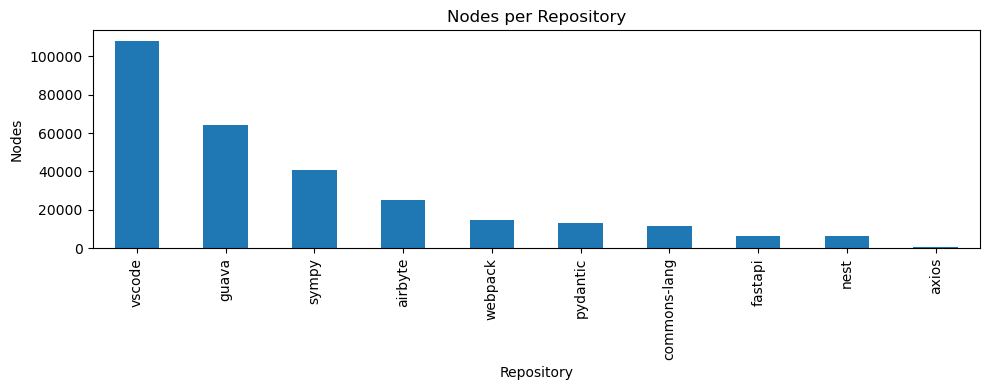

In [18]:
if plt is None:
    print('matplotlib unavailable')
else:
    plot_df = repo_df.sort_values('structure.nodes', ascending=False)
    ax = plot_df.plot(kind='bar', x='repo', y='structure.nodes', figsize=(10, 4), legend=False)
    ax.set_title('Nodes per Repository')
    ax.set_ylabel('Nodes')
    ax.set_xlabel('Repository')
    plt.tight_layout()


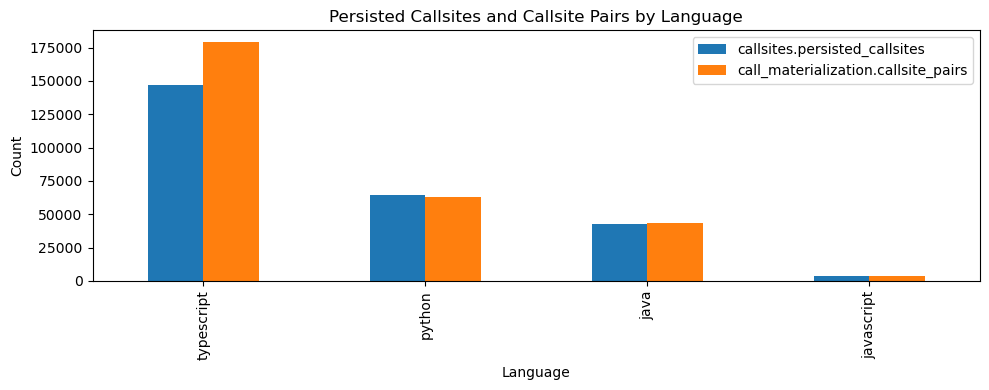

In [19]:
if plt is None:
    print('matplotlib unavailable')
else:
    plot_df = language_totals.sort_values('call_materialization.callsite_pairs', ascending=False)
    ax = plot_df.plot(kind='bar', x='language', y=['callsites.persisted_callsites', 'call_materialization.callsite_pairs'], figsize=(10, 4))
    ax.set_title('Persisted Callsites and Callsite Pairs by Language')
    ax.set_ylabel('Count')
    ax.set_xlabel('Language')
    plt.tight_layout()


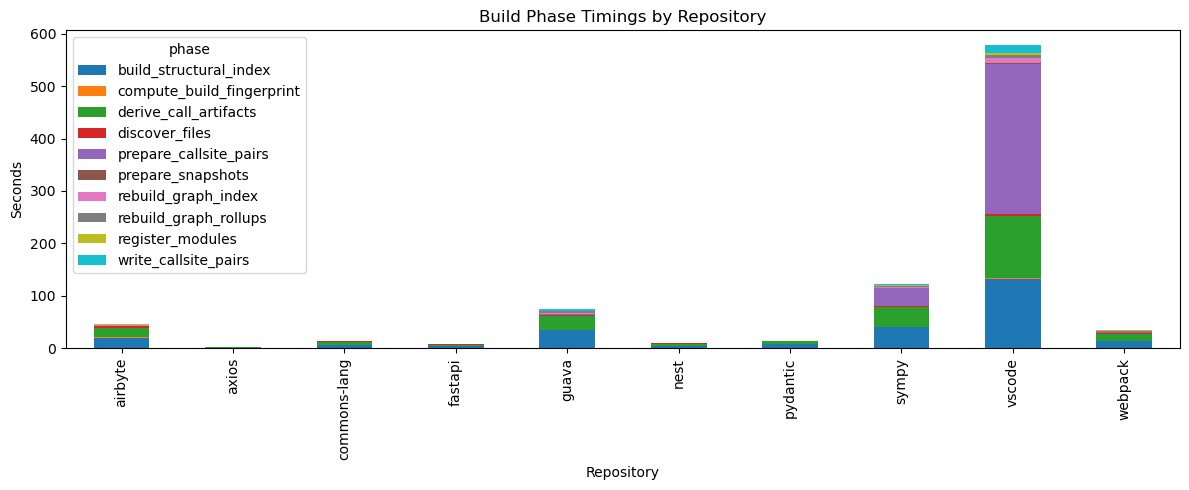

In [20]:
if plt is None:
    print('matplotlib unavailable')
else:
    plot_df = phase_wide_df.fillna(0)
    ax = plot_df.plot(kind='bar', stacked=True, figsize=(12, 5))
    ax.set_title('Build Phase Timings by Repository')
    ax.set_ylabel('Seconds')
    ax.set_xlabel('Repository')
    plt.tight_layout()


## Comparison Views

The following grouped charts compare the four main report areas across languages and between scopes (`non_tests`, `tests`).


### Structure


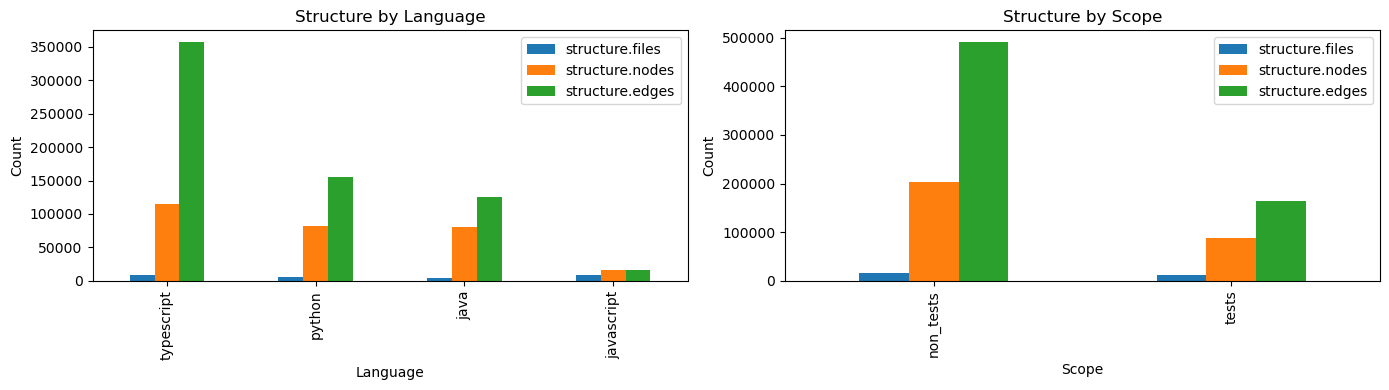

In [21]:
if plt is None:
    print('matplotlib unavailable')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    lang_plot = language_totals.sort_values('structure.nodes', ascending=False)
    lang_plot.plot(
        kind='bar',
        x='language',
        y=['structure.files', 'structure.nodes', 'structure.edges'],
        ax=axes[0],
    )
    axes[0].set_title('Structure by Language')
    axes[0].set_xlabel('Language')
    axes[0].set_ylabel('Count')

    scope_plot = scope_totals.sort_values('scope').set_index('scope')
    scope_plot[['structure.files', 'structure.nodes', 'structure.edges']].plot(
        kind='bar',
        ax=axes[1],
    )
    axes[1].set_title('Structure by Scope')
    axes[1].set_xlabel('Scope')
    axes[1].set_ylabel('Count')
    plt.tight_layout()


### Callsites


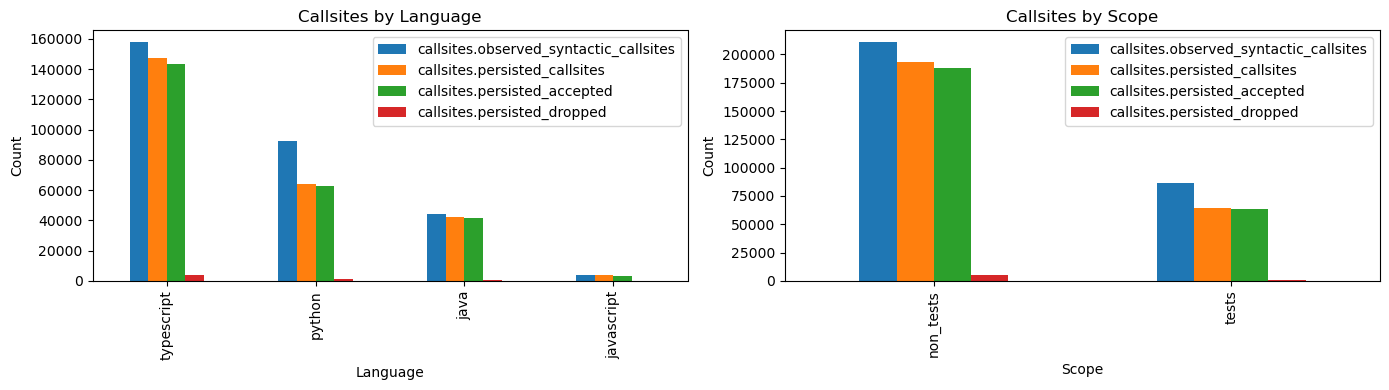

In [22]:
if plt is None:
    print('matplotlib unavailable')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    lang_plot = language_totals.sort_values('callsites.observed_syntactic_callsites', ascending=False)
    lang_plot.plot(
        kind='bar',
        x='language',
        y=[
            'callsites.observed_syntactic_callsites',
            'callsites.persisted_callsites',
            'callsites.persisted_accepted',
            'callsites.persisted_dropped',
        ],
        ax=axes[0],
    )
    axes[0].set_title('Callsites by Language')
    axes[0].set_xlabel('Language')
    axes[0].set_ylabel('Count')

    scope_plot = scope_totals.sort_values('scope').set_index('scope')
    scope_plot[[
        'callsites.observed_syntactic_callsites',
        'callsites.persisted_callsites',
        'callsites.persisted_accepted',
        'callsites.persisted_dropped',
    ]].plot(kind='bar', ax=axes[1])
    axes[1].set_title('Callsites by Scope')
    axes[1].set_xlabel('Scope')
    axes[1].set_ylabel('Count')
    plt.tight_layout()


### Filter


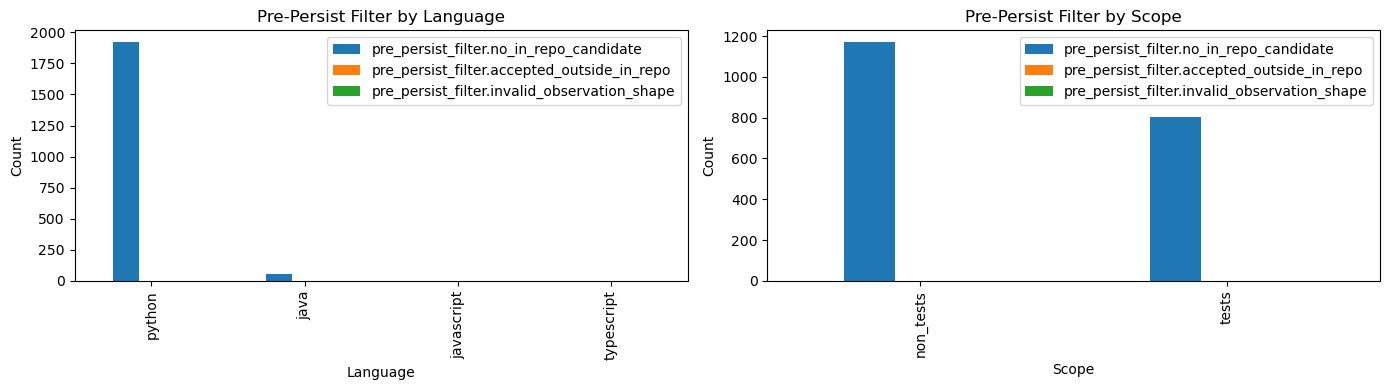

In [23]:
if plt is None:
    print('matplotlib unavailable')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    lang_plot = language_totals.sort_values('pre_persist_filter.no_in_repo_candidate', ascending=False)
    lang_plot.plot(
        kind='bar',
        x='language',
        y=[
            'pre_persist_filter.no_in_repo_candidate',
            'pre_persist_filter.accepted_outside_in_repo',
            'pre_persist_filter.invalid_observation_shape',
        ],
        ax=axes[0],
    )
    axes[0].set_title('Pre-Persist Filter by Language')
    axes[0].set_xlabel('Language')
    axes[0].set_ylabel('Count')

    scope_plot = scope_totals.sort_values('scope').set_index('scope')
    scope_plot[[
        'pre_persist_filter.no_in_repo_candidate',
        'pre_persist_filter.accepted_outside_in_repo',
        'pre_persist_filter.invalid_observation_shape',
    ]].plot(kind='bar', ax=axes[1])
    axes[1].set_title('Pre-Persist Filter by Scope')
    axes[1].set_xlabel('Scope')
    axes[1].set_ylabel('Count')
    plt.tight_layout()


### Calls


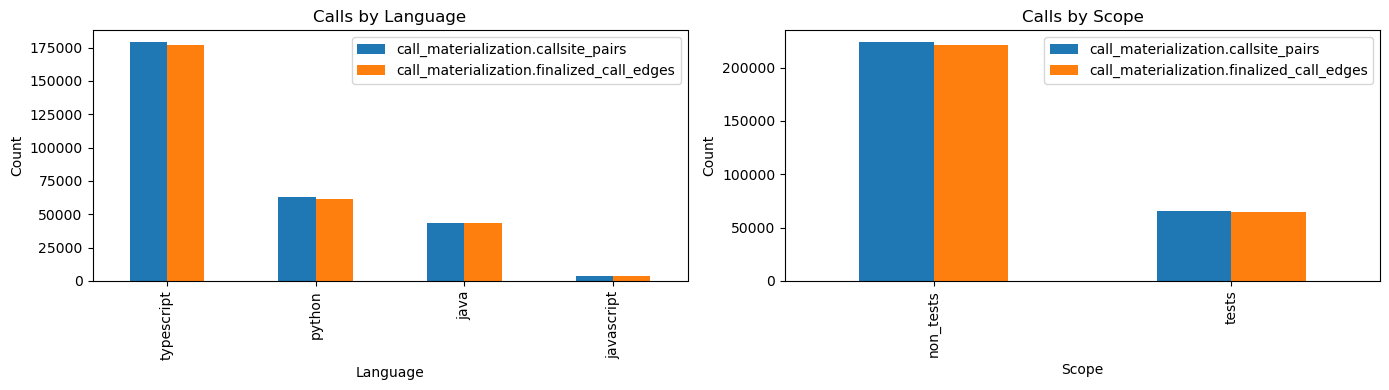

In [24]:
if plt is None:
    print('matplotlib unavailable')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    lang_plot = language_totals.sort_values('call_materialization.callsite_pairs', ascending=False)
    lang_plot.plot(
        kind='bar',
        x='language',
        y=['call_materialization.callsite_pairs', 'call_materialization.finalized_call_edges'],
        ax=axes[0],
    )
    axes[0].set_title('Calls by Language')
    axes[0].set_xlabel('Language')
    axes[0].set_ylabel('Count')

    scope_plot = scope_totals.sort_values('scope').set_index('scope')
    scope_plot[['call_materialization.callsite_pairs', 'call_materialization.finalized_call_edges']].plot(
        kind='bar',
        ax=axes[1],
    )
    axes[1].set_title('Calls by Scope')
    axes[1].set_xlabel('Scope')
    axes[1].set_ylabel('Count')
    plt.tight_layout()


## Raw Access

The objects below provide direct access to all loaded data.


In [25]:
list(reports.keys())


['airbyte',
 'axios',
 'commons-lang',
 'fastapi',
 'guava',
 'nest',
 'pydantic',
 'sympy',
 'vscode',
 'webpack']

In [26]:
report_for(sorted(reports)[0])


{'repo_root': '.',
 'tool_version': '0.1.0.dev789',
 'schema_version': '1.0',
 'snapshot_count': 1,
 'latest_snapshot': '93b007d0441b1d5d2cd74f0231a51a228454a408cf78ec9583990529f33b26e8',
 'latest_created': '2026-03-14T10:22:04.173900+00:00',
 'db_exists': True,
 'artifact_db_available': True,
 'report': {'artifact_db_available': True,
  'labels': {'sections': {'structure': 'Structure',
    'callsites': 'Callsites',
    'pre_persist_filter': 'Pre-Persist Filter',
    'call_materialization': 'Call Materialization',
    'timing': 'Timing'},
   'fields': {'files': 'Files',
    'nodes': 'Nodes',
    'edges': 'Edges',
    'observed_syntactic_callsites': 'Observed Syntactic Callsites',
    'filtered_pre_persist': 'Filtered Pre-Persist',
    'persisted_callsites': 'Persisted Callsites',
    'persisted_accepted': 'Persisted Accepted',
    'persisted_dropped': 'Persisted Dropped',
    'no_in_repo_candidate': 'No In-Repo Candidate',
    'accepted_outside_in_repo': 'Accepted Outside In-Repo',
   